In [1]:
from go_ml.train_utils import get_dataloaders
train_loader, val_loader = get_dataloaders()

/home/andrew/anaconda3/envs/gointerp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.27317815417177815
train len 124524 val len 31131


In [1]:
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
    

In [2]:
print(len(go_terms))

29185


In [2]:

batch = next(iter(val_loader))
print(batch['prot_id'])
for i in range(batch['labels'].shape[0]):
    print(batch['prot_id'][i], list(batch['labels'][i].nonzero().flatten().numpy()))

['Q86WR7', 'P92549', 'Q5JDG6', 'P73638', 'Q10835', 'P25390', 'Q1L721', 'P87154', 'O60784', 'Q16763', 'Q13422', 'P53043', 'P51130', 'E9PW05', 'F4KBP5', 'A8WTE8', 'Q5HZA3', 'Q9Z0Y9', 'P9WNA9', 'Q9SJ11', 'Q04513', 'Q4SFA0', 'Q2FZ23', 'Q99N02']
Q86WR7 [1, 72]
P92549 [3, 8, 21, 26, 62, 65, 72, 79, 103, 115, 123, 124, 131, 133, 159, 211, 271, 278, 286, 322, 350, 404, 415, 548, 585, 611, 665, 667, 722, 903, 976, 978, 996, 1010, 1091, 1106, 1147, 1165, 1217, 1245, 1398, 1685, 1872, 2016, 2047, 2217, 2343, 2732, 3009, 3075, 3090, 3318, 3526, 4072, 5575, 5609, 5673, 6164, 6391, 7247, 8154, 9617, 10860, 11941, 12895, 13082, 15168, 16118, 17346, 17937, 18293, 18745, 18956, 19255, 19981, 20121, 21237, 23049, 23738, 27643, 27912]
Q5JDG6 [5, 72, 521, 1121, 3009, 3023]
P73638 [17, 21, 72]
Q10835 [5, 14, 21, 29, 65, 69, 72, 103, 141, 189, 222, 434, 843, 1121, 1331, 1394, 1568, 2120, 2473, 2679, 3009, 3023, 3413, 3869, 4881, 5830, 6423, 8349, 9826, 27655, 28914]
P25390 [1, 9, 21, 32, 36, 65, 72, 75, 76,

In [3]:
import torch
device = torch.device('cuda:0')

In [4]:
import torch
import pickle
from go_ml.models.bert_finetune import BERTFinetune
checkpoint_dir = "/home/andrew/GO_interp/checkpoints"
with open(f"{checkpoint_dir}/esm_finetune_hparams.pkl", "rb") as f:
    hparams = pickle.load(f)
model = BERTFinetune.load_from_checkpoint(f"{checkpoint_dir}/esm_finetune.ckpt", model_args=hparams, 
                                          map_location=device)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
batch = next(iter(val_loader))
inputs, mask, y = batch['seq'].to(device), batch['mask'].to(device), batch['labels'].to(device)
gopred = model(inputs, mask)
print(gopred.shape)
print(batch.keys())

torch.Size([24, 29185])
dict_keys(['seq', 'labels', 'prot_id', 'mask'])


In [6]:
val_dataset = val_loader.dataset
val_labels = val_dataset.labels

In [7]:
def go_term_forward(model, go_idx):
    def forward_with_sigmoid(input, mask):
        return torch.sigmoid(model(input, mask)[:, go_idx])
    return forward_with_sigmoid

import torch.nn as nn
class SingleGOModel(nn.Module):
    def __init__(self, model, go_idx):
        super().__init__()
        self.model = model
        self.go_idx = go_idx

    def forward(self, seq, mask):
        return torch.sigmoid(self.model(seq, mask)[:, self.go_idx])

go260_model = SingleGOModel(model, 260)
print(go260_model(batch['seq'].to(device), batch['mask'].to(device)))

tensor([6.8144e-04, 6.9459e-05, 1.7121e-03, 5.1938e-05, 2.3130e-03, 1.1353e-03,
        9.7129e-04, 1.0276e-02, 4.4581e-04, 4.6098e-04, 8.1841e-01, 1.8054e-04,
        8.9144e-05, 8.3278e-01, 7.0186e-02, 4.1407e-03, 1.5780e-02, 9.1471e-01,
        3.6845e-04, 1.2777e-04, 6.4256e-05, 1.2426e-01, 7.0792e-04, 1.2432e-02],
       device='cuda:0', grad_fn=<SigmoidBackward0>)


In [8]:
print(go260_model(batch['seq'].to(device), batch['mask'].to(device)))

tensor([6.8144e-04, 6.9459e-05, 1.7121e-03, 5.1938e-05, 2.3130e-03, 1.1353e-03,
        9.7129e-04, 1.0276e-02, 4.4581e-04, 4.6098e-04, 8.1841e-01, 1.8054e-04,
        8.9144e-05, 8.3278e-01, 7.0186e-02, 4.1407e-03, 1.5780e-02, 9.1471e-01,
        3.6845e-04, 1.2777e-04, 6.4256e-05, 1.2426e-01, 7.0792e-04, 1.2432e-02],
       device='cuda:0', grad_fn=<SigmoidBackward0>)


In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, AutoModelForSeq2SeqLM, AutoConfig
tokenizer = AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
config = AutoConfig.from_pretrained('facebook/esm2_t6_8M_UR50D')

In [60]:
from captum.attr import LayerIntegratedGradients, TokenReferenceBase, visualization
token_reference = TokenReferenceBase(reference_token_idx=0)
lig = LayerIntegratedGradients(go260_model, go260_model.model.model.embeddings.word_embeddings)

In [61]:
batch_idx = batch['prot_id'].index('Q13422')
seq = batch['seq'][batch_idx:batch_idx+1]
mask = batch['mask'][batch_idx:batch_idx+1]
# gopred = model(seq.to(device), mask.to(device))

text = tokenizer.convert_ids_to_tokens(seq.flatten())
seq_length = seq.shape[1]

reference_indices = token_reference.generate_reference(seq_length, device=device).unsqueeze(0)
pred = go260_model(seq.to(device), mask.to(device)).item()


In [62]:
print(len(text))
print

1024


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [63]:
attributions_ig, delta = lig.attribute(seq.to(device), reference_indices, \
                                           n_steps=8, return_convergence_delta=True, 
                                           additional_forward_args=mask.to(device))

In [13]:
lig = None
torch.cuda.empty_cache()

In [64]:
attributions = attributions_ig.sum(dim=2).squeeze(0)
attributions = attributions / torch.norm(attributions)
attributions = attributions.cpu().detach().numpy()
seq_vis = visualization.VisualizationDataRecord(attributions[:200], pred, 1, 1, 1, attributions.sum(), text[:200], delta)

In [65]:
attributions_ig.shape

torch.Size([1, 1024, 320])

In [67]:
from IPython.display import display, HTML
from captum.attr._utils.visualization import format_word_importances
dom = format_word_importances(text[:520], attributions[:520])
html = HTML("".join(dom))
display(html)

In [69]:
visualization.visualize_text([seq_vis])

torch.Size([1, 1024, 320])


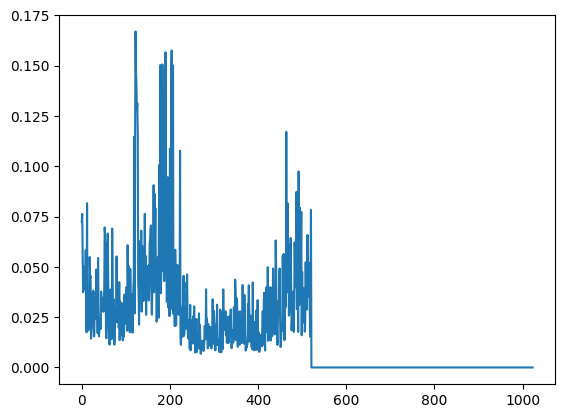

In [33]:
go260_model.go_idx = 260
lig = LayerIntegratedGradients(go260_model, go260_model.model.model.embeddings.word_embeddings)
attributions_ig, delta = lig.attribute(seq.to(device), reference_indices, \
                                           n_steps=8, return_convergence_delta=True, 
                                           additional_forward_args=mask.to(device))
print(attributions_ig.shape)
# attributions = attributions_ig.sum(dim=2).squeeze(0)
attributions = torch.norm(attributions_ig, dim=2).squeeze(0)
attributions = attributions / torch.norm(attributions)
attributions = attributions.cpu().detach().numpy()
import matplotlib.pyplot as plt
plt.plot(attributions)


In [ ]:
print(attributions_ig.shape)
attributions = attributions_ig.sum(dim=2).squeeze(0)
attributions = attributions / torch.norm(attributions)
attributions = attributions.cpu().detach().numpy()
import matplotlib.pyplot as plt
plt.plot(attributions)


torch.Size([1, 1024, 320])


In [ ]:
vis_data_records_ig = []

def interpret_sentence(model, seq_tokens, tokenizer, label = 0):
    model.zero_grad()

    input_indices = torch.tensor(seq_tokens, device=device)
    input_indices = input_indices.unsqueeze(0)
    
    # input_indices dim: [sequence_length]
    seq_length = seq_tokens.shape[1]

    # predict
    pred = go_260(input_indices).item()
    # pred_ind = round(pred)

    # generate reference indices for each sample
    reference_indices = token_reference.generate_reference(seq_length, device=device).unsqueeze(0)

    # compute attributions and approximation delta using layer integrated gradients
    attributions_ig, delta = lig.attribute(input_indices, reference_indices, \
                                           n_steps=500, return_convergence_delta=True)

    print('pred: ', pred, '(', '%.2f'%pred, ')', ', delta: ', abs(delta))

    add_attributions_to_visualizer(attributions_ig, text, pred, label, delta, vis_data_records_ig)

def add_attributions_to_visualizer(attributions, text, pred, label, delta, vis_data_records):
    attributions = attributions.sum(dim=2).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    attributions = attributions.cpu().detach().numpy()

    # storing couple samples in an array for visualization purposes
    vis_data_records.append(visualization.VisualizationDataRecord(
                            attributions,
                            pred,
                            Label.vocab.itos[pred_ind],
                            1,
                            Label.vocab.itos[1],
                            attributions.sum(),
                            text,
                            delta))
    

In [ ]:
import torch
from captum.attr import (
    IntegratedGradients,
    Saliency,
    InputXGradient,
    DeepLift,
    DeepLiftShap,
    GuidedBackprop,
    GuidedGradCam,
    Deconvolution,
    LRP
)
from torch.nn import functional as F
import transformers

model = AutoModel.from_pretrained('facebook/esm2_t6_8M_UR50D')
tokenizer = AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
config = AutoConfig.from_pretrained('facebook/esm2_t6_8M_UR50D')
device = torch.device("cuda:0")
model.to(device)
model.eval()
model.zero_grad()

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
